In [1]:
import os
import sys

from dotenv import load_dotenv

load_dotenv("../../.env")

# src 디렉토리를 Python path에 추가
sys.path.insert(0, os.path.abspath("../src"))

%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="LangSmith now uses UUID v7", 
    category=UserWarning,
)

## Context Isolation: Sub-agents

<img src="./assets/agent_header_subagent.png" width="800" style="display:block; margin-left:0;">

대화가 진행됨에 따라 에이전트의 컨텍스트는 빠르게 증가할 수 있으며, 이는 여러 가지 컨텍스트 관련 문제를 야기합니다. 주요 문제 중 하나는 컨텍스트 충돌 또는 혼란으로, 동일한 컨텍스트 창 내에서 서로 상충되는 목표가 존재할 경우 성능이 저하될 수 있습니다.   
[컨텍스트 격리](https://blog.langchain.com/context-engineering-for-agents/)는 각기 고립된 컨텍스트 창 내에서 작동하는 [전문화된 하위 에이전트](https://www.anthropic.com/engineering/multi-agent-research-system)에게 작업을 위임함으로써 효과적인 해결책을 제공합니다.   
이 접근 방식은 집중적이고 전문적인 작업 실행을 가능하게 하면서, 동시에 컨텍스트 충돌, 혼란, 오염 및 희석 현상을 방지합니다.



### Sub-agent delegation
![./assets/subagents.png](./assets/subagents.png)

핵심적인 통찰은 특정 작업에 맞춰 서로 다른 도구 세트를 갖춘 하위 에이전트를 생성할 수 있다는 점입니다.   
각 하위 에이전트는 `subagent_type`을 키로 하는 레지스트리 사전(dictionary)에 저장되며, 이를 통해 메인 에이전트는 `task(description, subagent_type)` 도구 호출을 통해 작업을 위임할 수 있습니다.   
서브 에이전트는 부모 에이전트의 컨텍스트와 완전히 분리된 상태에서 작동하며, 그 결과는 `ToolMessage` 형태로 부모 에이전트에 반환되어 관심사의 명확한 분리를 유지합니다.

<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>Note:</b>  
The <code>create_react_agent</code> was moved from the LangGraph library to the LangChain library and renamed to <code>create_agent</code> in the 1.0 code release post-filming. There are slight changes to the imports and code to accommodate this. The video may display the previous configuration.
</div>

## Step 1: Create Sub Agents

사용자가 하위 에이전트를 어떻게 지정할지 정의해 봅시다
```python
from typing_extensions import TypedDict

class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]
```

우리는 이러한 객체 목록을 사용하여 접근 권한이 있는 모든 하위 에이전트를 생성할 것입니다

```python
agents: list[SubAgent] = ...
subagents = {
    agent['name']: create_react_agent(
        model=model,
        prompt=agent['prompt'],
        tools = get_tools(agent['tools']),
        ...
    )
}
```

## Step 2: Create a tool to use Sub Agents

논리적으로 보면 대략 다음과 같아야 합니다:

```python
def task(
    description: str  # The task the subagent should do
    subagent_type: str  # Which subagent to use
):
    # Create new messages to pass to subagent - should just be the description
    # Call sub agent
    # Update state with both the subagents response AND any changes to file system
```

결국 전체적으로 다음과 같이 보입니다:

```python
@tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
def task(
    description: str,
    subagent_type: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
):
    """Delegate a task to a specialized sub-agent with isolated context.

    This creates a fresh context for the sub-agent containing only the task description,
    preventing context pollution from the parent agent's conversation history.
    """
    # Validate requested agent type exists
    if subagent_type not in agents:
        return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

    # Get the requested sub-agent
    sub_agent = agents[subagent_type]

    # Create isolated context with only the task description
    # This is the key to context isolation - no parent history
    state["messages"] = [{"role": "user", "content": description}]

    # Execute the sub-agent in isolation
    result = sub_agent.invoke(state)

    # Return results to parent agent via Command state update
    return Command(
        update={
            "files": result.get("files", {}),  # Merge any file changes
            "messages": [
                # Sub-agent result becomes a ToolMessage in parent context
                ToolMessage(
                    result["messages"][-1].content, tool_call_id=tool_call_id
                )
            ],
        }
    )

return task
```

In [3]:
%%writefile ../src/deep_agents_from_scratch/task_tool.py
"""Task delegation tools for context isolation through sub-agents.

This module provides the core infrastructure for creating and managing sub-agents
with isolated contexts. Sub-agents prevent context clash by operating with clean
context windows containing only their specific task description.
"""

from typing import Annotated, NotRequired
from typing_extensions import TypedDict

from langchain_core.messages import ToolMessage
from langchain_core.tools import BaseTool, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState  # updated 1.0
from langchain.agents import create_agent  # updated 1.0

from langgraph.types import Command

from deep_agents_from_scratch.prompts import TASK_DESCRIPTION_PREFIX
from deep_agents_from_scratch.state import DeepAgentState


class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """서브 에이전트를 통해 컨텍스트 격리가 가능한 작업 위임 도구를 생성

    이 함수는 격리된 컨텍스트를 가진 특화된 서브 에이전트를 생성하는 핵심 패턴을 구현하여,
    복잡한 다단계 작업에서 발생하는 컨텍스트 충돌과 혼란을 방지합니다.

    Args:
        tools: 서브 에이전트에 할당할 수 있는 사용 가능한 도구 목록
        subagents: 특수화된 서브 에이전트 구성 목록
        model: 모든 에이전트에 사용할 언어 모델
        state_schema: 상태 스키마 (일반적으로 DeepAgentState)

    Returns:
        특수화된 서브 에이전트에 작업을 위임할 수 있는 ‘task’ 도구
    """
    # Create agent registry
    agents = {}

    # Build tool name mapping for selective tool assignment
    tools_by_name = {}
    for tool_ in tools:
        if not isinstance(tool_, BaseTool):
            tool_ = tool(tool_)
        tools_by_name[tool_.name] = tool_

    # Create specialized sub-agents based on configurations
    for _agent in subagents:
        if "tools" in _agent:
            # Use specific tools if specified
            _tools = [tools_by_name[t] for t in _agent["tools"]]
        else:
            # Default to all tools
            _tools = tools
        agents[_agent["name"]] = create_agent(   # updated 1.0
            model, system_prompt=_agent["prompt"], tools=_tools, state_schema=state_schema
        )

    # Generate description of available sub-agents for the tool description
    other_agents_string = [
        f"- {_agent['name']}: {_agent['description']}" for _agent in subagents
    ]

    @tool(description=TASK_DESCRIPTION_PREFIX.format(other_agents=other_agents_string))
    def task(
        description: str,
        subagent_type: str,
        state: Annotated[DeepAgentState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """작업의 컨텍스트를 분리하여 전문 sub-agent에게 위임합니다.

        이렇게 하면 작업 설명만 포함된 새로운 컨텍스트가 sub-agent에 생성되어,
        상위 agent의 대화 기록으로 인한 컨텍스트 오염을 방지합니다.
        """
        # Validate requested agent type exists
        if subagent_type not in agents:
            return f"Error: invoked agent of type {subagent_type}, the only allowed types are {[f'`{k}`' for k in agents]}"

        # Get the requested sub-agent
        sub_agent = agents[subagent_type]

        # Create isolated context with only the task description
        # This is the key to context isolation - no parent history
        state["messages"] = [{"role": "user", "content": description}]

        # Execute the sub-agent in isolation
        result = sub_agent.invoke(state)

        # Return results to parent agent via Command state update
        return Command(
            update={
                "files": result.get("files", {}),  # Merge any file changes
                "messages": [
                    # Sub-agent result becomes a ToolMessage in parent context
                    ToolMessage(
                        result["messages"][-1].content, tool_call_id=tool_call_id
                    )
                ],
            }
        )

    return task

Overwriting ../src/deep_agents_from_scratch/task_tool.py


이제 도구를 통해 하위 에이전트를 생성하는 루틴이 준비되었습니다.   
이제 특정 하위 에이전트를 정의하고, 시스템이 `task` 도구를 사용하여 이를 호출하도록 할 수 있습니다.    
위에서 `_create_task_tool`은 `SubAgent` 유형의 리스트를 인수로 받습니다. 이 리스트에는 생성될 에이전트들에 대한 설명이 포함되어 있습니다. 

```python
class SubAgent(TypedDict):
    """Configuration for a specialized sub-agent."""

    name: str
    description: str
    prompt: str
    tools: NotRequired[list[str]]


def _create_task_tool(tools, subagents: list[SubAgent], model, state_schema):
    """Create a task delegation tool that enables context isolation through sub-agents.

```
`SubAgent` 클래스는 하위 에이전트의 이중 역할을 수행하는 데 필요한 고유한 정보를 정의합니다. 하위 에이전트는 도구이자 에이전트로서 기능합니다.  

- **도구로서**, 서브에이전트는 자신의 기능과 호출 방법에 대한 정보를 슈퍼바이저 에이전트에 제공합니다.  
- **에이전트로서**, 서브에이전트는 자신의 작업을 수행하는 방법을 설명하는 프롬프트와 해당 작업에 필요한 도구 세트가 필요합니다.  

아래에서는 연구 서브에이전트를 생성할 것입니다. 이 서브에이전트의 `description`은 슈퍼바이저 에이전트에게 단일 작업을 이 서브에이전트에 위임해야 함을 알립니다. `SIMPLE_RESEARCH_INSTRUCTIONS`는 하위 에이전트가 연구를 수행하는 데 사용하는 프롬프트입니다. 이 예제에서는 간략하게 작성되었지만, 범용 연구자의 경우 훨씬 더 상세하게 작성될 수 있습니다. 또한 하위 에이전트에게는 연구 과정에서 사용할 `web_search` 도구가 제공됩니다.  

```python
# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}
```

서브에이전트는 특정 작업과 이를 완료하는 데 필요한 도구를 함께 전달받습니다. 하위 에이전트는 해당 단일 작업 설명으로 제한된 자체 컨텍스트 내에서 작동합니다. 이러한 [컨텍스트 엔지니어링](https://blog.langchain.com/context-engineering-for-agents/) 접근 방식은 하위 에이전트의 작업 컨텍스트가 컨텍스트 충돌, 혼란, 오염, 희석 현상으로부터 자유로울 수 있도록 보장합니다.

이제 슈퍼바이저 에이전트의 프롬프트에는 이러한 서브 에이전트를 호출하고 사용하는 방법에 대한 설명이 포함되어야 합니다. 이는 아래에 나와 있습니다. *사용 가능한 도구*에 대한 설명과, 해당되는 경우 병렬 연구를 활용하라는 지침에 유의하십시오.

In [4]:
from utils import show_prompt

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS

show_prompt(SUBAGENT_USAGE_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  당신은 sub-agent에게 업무(Task)를 위임할 수 있습니다.                                                          │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  당신의 역할은 sub-agent들에게 구체적인 연구 과제를 할당하여 연구를 총괄하는 것입니다.                          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  1. **task(description, subagent_type)**: 전문 sub-agent에게 연구 과제를 위임합니다.                            │
│     - description: 명확하고 구체적인 연구 질문 또는 과제                                                        │
│     - subagent_type: 사용할 agent 유형 (예: “research-agent”)                                                   │
│  2. **think_tool(reflection)**: 위임된 각 작업의 결과를 검토하고 다음 단계를 계획합니다.                        │
│     - reflection: 작업 결과 및 다음 단계에 대한 상세한 검토 내용.                                               │
│                                                                                                                 │
│  **병렬 연구**: 서로 독립적인 여러 연구 방향을 식별한 경우, 병렬 실행을 가능하게 하려면 단일 응답 내에서 여러   │
│  개의 **작업** 도구 호출을 수행하십시오. 반복당 최대 {max_concurrent_research_units}개의 병렬 에이전트를        │
│  사용하십시오.                                                                                                  │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **작업 위임 예산** (과도한 위임 방지):                                                                         │
│  - **집중적인 조사에 중점을 두기** - 간단한 질문에는 단일 sub-agent를 사용하고, 명백히 이점이 있거나 사용자의   │
│  요청에 따라 여러 개의 독립적인 조사 방향이 필요한 경우에만 여러 agent를 사용하십시오.                          │
│  - **충분할 때 중단** - 과도하게 조사하지 말고, 충분한 정보를 얻었을 때 중단하십시오.                           │
│  - **반복 횟수 제한** - 적절한 출처를 찾지 못한 경우, {max_researcher_iterations}번의 작업 위임 후              │
│  중단하십시오.                                                                                                  │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│  <Scaling Rules>                                                                                                │
│  **단순한 사실 확인, 목록 작성 및 순위 매기기**에는 단일 sub-agent를 사용할 수 있습니다:                        │
│  - *예시*: “샌프란시스코의 상위 10개 커피숍을 나열해 주세요” → sub-agent 1개 사용,                              │
│  `findings_coffee_shops.md`에 저장                                                                              │
│                                                                                                                 │
│  **비교**의 경우, 비교 대상 요소마다 하나의 sub-agent를 사용할 수 있습니다:                                     │
│  - *예시*: “OpenAI, Anthropic, DeepMind의 AI 안전성 접근 방식을 비교하라” → sub-agent 3개 사용                  │
│  - 조사 결과를 별도의 파일에 저장: `findings_openai_safety.md`, `findings_anthropic_safety.md`,                 │
│  `findings_deepmind_safety.md`                                                                                  │
│                                                            

이제 슈퍼바이저와 서브 에이전트로 구성된 검색 시스템을 만들어 보겠습니다. 
이번에는 각 구성 요소가 어떻게 결합되는지 보여주기 위해 미리 정의된 검색 결과를 사용하는 시뮬레이션 버전으로만 구성할 것입니다. 다음 강의에서는 본격적인 검색 시스템을 구축하게 될 것입니다.

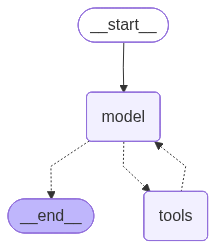

In [5]:
from datetime import datetime

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent # updated in 1.0

from deep_agents_from_scratch.prompts import SUBAGENT_USAGE_INSTRUCTIONS
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Mock search result
search_result = """The Model Context Protocol (MCP) is an open standard protocol developed 
by Anthropic to enable seamless integration between AI models and external systems like 
tools, databases, and other services. It acts as a standardized communication layer, 
allowing AI models to access and utilize data from various sources in a consistent and 
efficient manner. Essentially, MCP simplifies the process of connecting AI assistants 
to external services by providing a unified language for data exchange. """


# Mock search tool
@tool(parse_docstring=True)
def web_search(
    query: str,
):
    """Search the web for information on a specific topic.

    This tool performs web searches and returns relevant results
    for the given query. Use this when you need to gather information from
    the internet about any topic.

    Args:
        query: The search query string. Be specific and clear about what
               information you're looking for.

    Returns:
        Search results from the search engine.

    Example:
        web_search("machine learning applications in healthcare")
    """
    return search_result


# Add mock research instructions
SIMPLE_RESEARCH_INSTRUCTIONS = """당신은 연구원입니다. 주어진 주제에 대해 조사하십시오. 중요: web_search 도구를 한 번만 호출하고, 도구가 제공하는 결과를 활용하여 주어진 주제에 대한 답변을 작성하십시오."""

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": " ",
    "prompt": SIMPLE_RESEARCH_INSTRUCTIONS,
    "tools": ["web_search"],
}

# Create agent using create_react_agent directly
model = init_chat_model(model="anthropic:claude-sonnet-4-6", temperature=0.0)

# Tools for sub-agent
sub_agent_tools = [web_search]

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

# Tools
delegation_tools = [task_tool]

# Create agent with system prompt
agent = create_agent(
    model,
    delegation_tools,
    system_prompt=SUBAGENT_USAGE_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
        date=datetime.now().strftime("%a %b %-d, %Y"),
    ),
    state_schema=DeepAgentState,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [6]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Model Context Protocol(MCP)에 대해 간략히 설명해 주세요.",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Model Context Protocol(MCP)에 대해 간략히 설명해 주세요.                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: task                                                                                              │
│    Args: {                                                                                                      │
│   "description": "Model Context Protocol(MCP)에 대해 조사해 주세요. 다음 내용을 포함해 주세요:\n1. MCP의 정의   │
│ 및 개요\n2. MCP의 주요 목적과 필요성\n3. MCP의 핵심 구성 요소 및 아키텍처\n4. MCP의 주요 기능 및 특징\n5. MCP의 │
│ 활용 사례 및 지원 현황\n6. MCP의 장점과 의의\n\n최신 정보를 기반으로 명확하고 이해하기 쉽게 정리해 주세요.",    │
│   "subagent_type": "research-agent"                                                                             │
│ }                                                                                                               │
│    ID: toolu_012H8aLmHyAAT5qVM6xBk72V                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 검색 결과를 바탕으로 MCP에 대한 종합적인 조사 보고서를 작성하겠습니다.                                          │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 🔌 Model Context Protocol (MCP) 종합 조사 보고서                                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 1. MCP의 정의 및 개요                                                                                        │
│                                                                                                                 │
│ **Model Context Protocol(MCP)** 은 **Anthropic**이 2024년 말 공개한 **오픈 표준 프로토콜**로, AI 모델과 외부    │
│ 시스템(도구, 데이터베이스, 서비스 등) 간의 **원활한 통합을 가능하게 하는 표준화된 통신 계층**입니다.            │
│                                                                                                                 │
│ > 💡 한 마디로 정의하면, MCP는 **"AI 모델을 위한 USB-C 포트"** 와 같습니다.                                     │
│ > USB-C가 다양한 기기를 하나의 표준 인터페이스로 연결하듯, MCP는 AI 모델이 다양한 외부 데이터 소스 및 도구와    │
│ **일관되고 효율적인 방식**으로 소통할 수 있도록 합니다.                                                         │
│                                                                                                                 │
│ MCP는 특정 회사나 모델에 종속되지 않는 **개방형(Open) 표준**으로 설계되었으며, AI 어시스턴트가 외부 서비스에    │
│ 연결하는 과정을 **단일화된 데이터 교환 언어**로 단순화합니다.                                                   │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## 2. MCP의 주요 목적과 필요성                                                                                  │
│                                                                                                                 │
│ ### 🚨 기존의 문제점 — "M×N 통합 문제"                                                                          │
│                                                                                                                 │
│ MCP 등장 이전에는 AI 모델을 외부 시스템과 연결하기 위해 **각각의 조합마다 별도의 커스텀 통합(Custom             │
│ Integration)** 을 개발해야 했습니다.                                                                            │
│                                                                                                                 │
│ | 구분 | 기존 방식 | MCP 도입 후 |                                                                              │
│ |------|-----------|-------------|                                                                              │
│ | 통합 방식 | M개의 AI × N개의 도구 = M×N개의 커스텀 연결 | M+N (표준 프로토콜 하나로 해결) |                   │
│ | 유지보수 | 각 연결마다 개별 관리 필요 | 표준 인터페이스로 일괄 관리 |                                         │
│ | 확장성 | 새 도구 추가 시 모든 AI에 재작업 | 한 번 구현으로 모든 AI에 적용 |                                   │
│ | 보안 | 통합마다 보안 정책 상이 | 표준화된 보안 모델 적용 |                                                    │
│                                                                                                                 │
│ ### ✅ MCP가 해결하는 핵심 과제                                                                                 │
│                                

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ## 🔌 Model Context Protocol (MCP) 개요                                                                         │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 1. MCP란 무엇인가?                                                                                          │
│                                                                                                                 │
│ **Model Context Protocol(MCP)** 은 **Anthropic**이 2024년 말 공개한 **오픈 표준 프로토콜**로, AI 모델과 외부    │
│ 시스템(도구, 데이터베이스, 서비스 등) 간의 통신을 표준화한 규약입니다.                                          │
│                                                                                                                 │
│ > 💡 **한 줄 요약**: MCP는 **"AI를 위한 USB-C 포트"** — 다양한 외부 시스템을 하나의 표준 인터페이스로 AI에      │
│ 연결합니다.                                                                                                     │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 2. 왜 필요한가? (등장 배경)                                                                                 │
│                                                                                                                 │
│ MCP 이전에는 AI 모델을 외부 도구와 연결할 때 **M개의 AI × N개의 도구 = M×N개의 개별 커스텀 연결**이             │
│ 필요했습니다. MCP는 이를 **하나의 표준 프로토콜(M+N)** 로 해결합니다.                                           │
│                                                                                                                 │
│ | 구분 | 기존 방식 | MCP 도입 후 |                                                                              │
│ |------|-----------|-------------|                                                                              │
│ | 통합 수 | M × N개 (폭발적 증가) | M + N개 (표준화) |                                                          │
│ | 유지보수 | 각 연결마다 개별 관리 | 표준 인터페이스로 일괄 관리 |                                              │
│ | 확장성 | 새 도구 추가 시 전면 재작업 | 한 번 구현으로 모든 AI에 적용 |                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### 3. 핵심 아키텍처                                                                                            │
│                                                                                                                 │
│ MCP는 **클라이언트-서버(Client-Server)** 구조로 동작합니다.                                                     │
│                                                                                                                 │
│ ```                                                                                                             │
│ [MCP Host] ← (Claude, VS Code, Cursor 등 AI 실행 환경)                                                          │
│      │                                                                                                          │
│ [MCP Client] ← (프로토콜 통신 담당)                                                                             │
│      │  JSON-RPC 2.0                                                                      

Trace: 
https://smith.langchain.com/public/26cc1c2b-e785-4c6d-a2a7-c30a31875fc7/r
<!-- https://smith.langchain.com/public/edc4e672-db9c-457a-953d-f62e7813591c/r -->